# 01 — Stocks Table Exploration

Direct SQL consultation of `data/stocks.db` — the structured side of SIRA.
Run this after ingesting at least one CSV via `POST /upload-csv`.

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = Path('../data/stocks.db')
assert DB_PATH.exists(), f'Database not found at {DB_PATH.resolve()}'
con = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH.resolve())

Connected to /home/guimas/Documents/Software/sira/data/stocks.db


## Schema

In [2]:
schema = pd.read_sql(
    "SELECT name, sql FROM sqlite_master WHERE type='table' ORDER BY name",
    con,
)
schema

,name,sql
0,chunks,CREATE TABLE chunks (\n id INTEGE...
1,documents,CREATE TABLE documents (\n id INT...
2,metadata,"CREATE TABLE metadata (key TEXT PRIMARY KEY, v..."
3,sqlite_sequence,"CREATE TABLE sqlite_sequence(name,seq)"
4,stocks,"CREATE TABLE ""stocks"" (\n""isin"" TEXT,\n ""tick..."


## Row count and column names

In [3]:
df = pd.read_sql('SELECT * FROM stocks', con)
print(f'Rows: {len(df)}  |  Columns: {list(df.columns)}')
df.head()

Rows: 1749  |  Columns: ['isin', 'ticker', 'company_description', 'investment_case_teaser', 'investment_case_description', 'swot_analysis', 'esg_analysis', 'previous_recommendation', 'recommendation_date', 'recommendation_comment', 'focus_list_status', 'focus_list_status_date', 'focus_list_status_details', 'currency', 'price', 'price_date', 'target_price', 'target_price_ratio', 'target_price_date', 'price_52w_highest', 'price_52w_lowest', 'dividend_yield', 'beta', 'average_daily_shares_traded', 'market_capitalization', 'free_cash_flow_to_sales', 'earning_per_share_fy0', 'earning_per_share_fy1', 'earning_per_share_change_fy1', 'price_to_earning_historical_10y', 'price_to_earning_forward_12m', 'price_to_earning_fy1', 'price_to_earning_fy2', 'return_on_equity_forward_12m', 'return_on_equity_fy1', 'return_on_equity_fy2', 'return_on_capital_employed_fy1', 'return_on_capital_employed_fy2', 'net_debt_to_equity_fy1', 'net_debt_to_equity_fy2', 'net_debt_to_ebitda_forward_12m', 'net_debt_to_ebit

,isin,ticker,company_description,investment_case_teaser,investment_case_description,swot_analysis,esg_analysis,previous_recommendation,recommendation_date,recommendation_comment,...,blocking_codes,tax_rating,company,recommendation,sector_level_1,industry_group_level_2,industry_level_3,sub_industry_level_4,pwm_universe,region
0,GB0031274896,NaN,Marks & Spencer is a British multichannel reta...,NaN,<p>This security is part of the extended PWM i...,NaN,ESG Score Card for Marks and Spencer Group plc...,Not Covered,2025-05-13,<p>This security is part of the extended PWM i...,...,NaN,"- Client's country/type (ukrnd): Code: AVUK, N...",Marks & Spencer Group PLC,NaN,Consumer staples,Consumer Staples Distribution & Retail,Consumer Staples Distribution & Retail,Food Retail,1,Europe
1,US2774321002,NaN,Established in 1920 to produce chemicals for E...,NaN,<p>This security is part of the extended PWM i...,NaN,ESG Score Card for Eastman Chemical Company\n\...,Not Covered,2023-10-30,<p>This security is part of the extended PWM i...,...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",Eastman Chemical Co,NaN,Materials,Materials,Chemicals,Specialty Chemicals,1,North America
2,CNE1000008M8,NaN,China Pacific Insurance was established in 198...,NaN,<p>This security is part of the extended PWM i...,NaN,ESG Score Card for China Pacific Insurance (Gr...,Not Covered,2025-02-28,<p>This security is part of the extended PWM i...,...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",China Pacific Insurance (Group) Co Ltd,NaN,Financials,Insurance,Insurance,Multi-line Insurance,1,Asia
3,JP3566800003,NaN,"Central Japan Railway Company, or JR Central, ...",NaN,<p>This security is part of the extended PWM i...,NaN,ESG Score Card for Central Japan Railway Compa...,PWM Universe,2025-05-27,This security has been automatically removed f...,...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",Central Japan Railway Co,NaN,Industrials,Transportation,Ground Transportation,Rail Transportation,0,Asia
4,US49446R1095,NaN,One of the oldest real estate investment trust...,NaN,<p>This security is part of the extended PWM i...,NaN,ESG Score Card for Kimco Realty Corporation\n\...,Not Covered,2024-07-03,<p>This security is part of the extended PWM i...,...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",Kimco Realty Corp,NaN,Real estate,Equity Real Estate Inv. Trusts (REITs),Retail REITs,Retail REITs,1,North America


## Descriptive statistics

In [4]:
df.describe(include='all')

,isin,ticker,company_description,investment_case_teaser,investment_case_description,swot_analysis,esg_analysis,previous_recommendation,recommendation_date,recommendation_comment,...,blocking_codes,tax_rating,company,recommendation,sector_level_1,industry_group_level_2,industry_level_3,sub_industry_level_4,pwm_universe,region
count,1749,537,1702,368,1615,357,1590,1141,1747,1747,...,92,1742,1749,343,1737,1737,1737,1737,1749.000000,1741
unique,1749,532,1659,359,358,357,1547,7,289,474,...,17,80,1691,5,12,29,80,162,NaN,7
top,GB0031274896,DOW US,Not Covered,<p>Samsung Electronics is the largest memory m...,<p>This security is part of the extended PWM i...,SWOT Analysis for AMETEK INC (AME US)\n\nStren...,ESG Score Card for Carnival Corporation & plc\...,PWM Universe,2022-03-27,<p>This security is part of the extended PWM i...,...,- D333: Domicile: United States\n- N333: Natio...,"- Client's country/type (ukrnd): Code: UKTA, N...",Samsung Electronics Co Ltd,Buy,Industrials,Capital Goods,Banks,Diversified Banks,NaN,North America
freq,1,2,13,3,1250,1,3,479,157,513,...,74,855,3,151,263,173,101,93,NaN,896
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.572327,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.494883,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN


## Top 10 stocks by price

,isin,ticker,company_description,investment_case_teaser,investment_case_description,swot_analysis,esg_analysis,previous_recommendation,recommendation_date,recommendation_comment,...,blocking_codes,tax_rating,company,recommendation,sector_level_1,industry_group_level_2,industry_level_3,sub_industry_level_4,pwm_universe,region
854,KR7207940008,NaN,"Founded in 2011, Samsung Biologics is a South ...",NaN,<p>This security is part of the extended PWM i...,NaN,"ESG Score Card for Samsung Biologics Co.,Ltd.\...",PWM Universe,2025-10-23,This security has been automatically removed f...,...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",Samsung BioLogics Co Ltd,NaN,Health care,"Pharmaceuticals, biotechnology & life sciences",Life sciences tools & services,Life sciences tools & services,0,Asia
1164,KR7012450003,012450 KP,<p>Hanwha Aerospace is South Korea’s largest d...,<p>Global defense expenditure is expected to r...,- Rational N°1: Well Positioned in a Global De...,NaN,NaN,NaN,2025-11-03,"<p>On 3rd November, before market open, Hanwha...",...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",HANWHA AEROSPACE CO. LTD.,Buy,Industrials,Capital Goods,Aerospace & Defense,Aerospace & Defense,1,Asia
1728,US0846701086,BRK/A UN,<p>Berkshire Hathaway is a holding company wit...,"<p>Berkshire has become more defensive, even b...",- Rational N°1: 9th largest stock in S&P 500 a...,SWOT Analysis for Berkshire Hathaway Inc (BRK/...,Risks:\n- Product Service Mix: <p>Berkshire Ha...,NaN,2025-11-03,"<p>Yesterday, Berkshire released its 3Q25 resu...",...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",Berkshire Hathaway Inc,Hold,Financials,Financial Services,Financial Services,Multi-Sector Holdings,1,North America
991,KR7051900009,051900 KS,LG Household & Health Care is the 2nd largest ...,NaN,NaN,NaN,NaN,Hold,2022-04-28,"<p>Following the departure of the analyst, the...",...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",LG HOUSEHOLD & HEALTH CARE LTD,NaN,Consumer staples,Household & Personal Products,Personal Products,Personal Products,0,Asia
219,KR7000660001,000660 KP,<p>SK Hynix is the 2nd largest DRAM maker and ...,<p>We believe DRAM price will continue to rise...,- Rational N°1: DRAM price may go up further\n...,SWOT Analysis for SK hynix Inc (000660 KP)\n\n...,Risks:\n- Corporate Governance: <p>Quality and...,NaN,2025-10-29,<p><strong>3Q25 result in-line –</strong> reve...,...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",SK hynix Inc,Hold,Information technology,Semiconductors & Semiconductor Equipment,Semiconductors & Semiconductor Equipment,Semiconductors,1,Asia
1244,KR7329180004,329180 KP,<p>HD Hyundai Heavy Industries (HHI) operates ...,<p>We see a huge opportunity for HHI to captur...,- Rational N°1: Structural demand for alternat...,SWOT Analysis for HD HYUNDAI CO. LTD. (329180 ...,NaN,Caution,2025-07-22,<p>We drop coverage on Hyundai Heavy Industrie...,...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",HD HYUNDAI CO. LTD.,NaN,Energy,Energy,"Oil, Gas & Consumable Fuels",Oil & Gas Refining & Marketing,0,Asia
1494,KR7005380001,005380 KP,<p>Hyundai Motor Company (HMC) is the third la...,<p>We believe Hyundai Motor (HMC) is a global ...,- Rational N°1: Valuation discount to narrow w...,NaN,Risks:\n- Corporate Governance: <p>On corporat...,NaN,2025-11-03,"<p>On 30th October, after market close, Hyunda...",...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",Hyundai Motor Co Ltd,Hold,Consumer discretionary,Automobiles & Components,Automobiles,Automobile Manufacturers,1,Asia
8,KR7006400006,NaN,Samsung SDI is one of the top suppliers of lit...,NaN,<p>This security is part of the extended PWM i...,NaN,"ESG Score Card for Samsung SDI Co., Ltd.\n\n- ...",PWM Universe,2025-04-26,This security has been automatically removed f...,...,NaN,"- Client's country/type (ukrnd): Code: UKTA, N...",Samsung SDI Co Ltd,NaN,Information technology,Technology Hardware & Equipment,"Electronic Equipment,Instrument

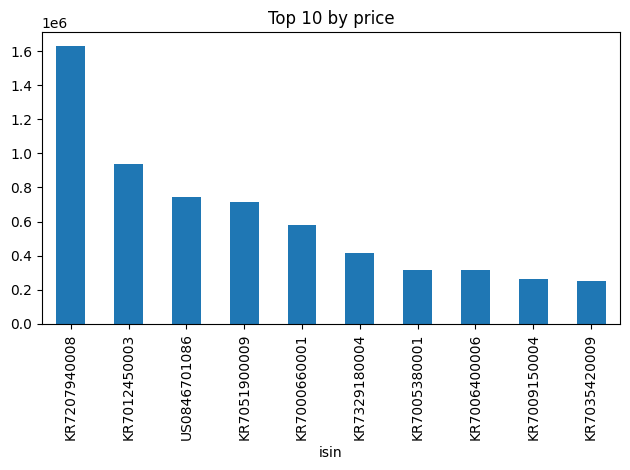

In [5]:
# Adjust the column name if your CSV uses a different price column.
numeric_cols = df.select_dtypes(include='number').columns.tolist()
if numeric_cols:
    price_col = numeric_cols[0]
    top10 = df.nlargest(10, price_col)
    display(top10)

    ticker_col = df.columns[0]  # assume first column is the ticker/name
    top10.plot.bar(x=ticker_col, y=price_col, legend=False, title=f'Top 10 by {price_col}')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns found — check your CSV structure.')

## Stored column metadata

In [6]:
pd.read_sql('SELECT * FROM metadata', con)

,key,value
0,columns,"isin,ticker,company_description,investment_cas..."


In [7]:
con.close()